# Teste End-to-End do Pipeline — 1 imagem

Este notebook valida o fluxo completo do projeto usando **uma única imagem** do MoNuSeg:

1. **Leitura** dos dados (imagem + máscara de ground truth);
2. **Pré-processamento** (Cellpose + RGBA);
3. **Treinamento** da MarkerNet através da rede final congelada (ScribblePrompt);
4. **Validações** automáticas (formas, gradiente, congelamento e convergência).

Fluxo do pipeline de treinamento:

```
imagem + RGBA → MarkerStep (MarkerNet diferenciável) → markers
→ FrozenSegmentationStep (ScribblePrompt congelado) → segmentation
→ LossComposer (dice + rmse + size) → backward até a MarkerNet
```

## 0. Setup

**Colab:** instale as dependências na célula abaixo (``requirements.txt`` fixa todas as versões; torch/torchvision preservam a build GPU do Colab).

**Local:** garanta que o ``.venv`` esteja ativo com as dependências instaladas.


In [13]:
# Clone the repository containing the project code
import sys
import os
repo_dir = 'cell-fuzzy-seg'
# if not os.path.exists(repo_dir):
#     !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

[Errno 2] No such file or directory: 'cell-fuzzy-seg'
/content/cell-fuzzy-seg


In [14]:
# Instala as dependências (apenas no Colab / primeira execução)
import sys

if "google.colab" in sys.modules:
    get_ipython().system("python -m pip install -r requirements.txt -q")
else:
    print("Ambiente local: verifique se as dependências estão instaladas no .venv.")

: 

## 1. Imports e dispositivo

In [15]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Garante que a raiz do projeto esteja no path (robusto para upload/clone no Colab)
ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.data.load.monuseg_dataset import MonusegDataset
from src.pipeline.preprocessing_pipeline import PreprocessingPipeline
from src.pipeline.steps.preprocessing.cellpose_step import CellposeStep
from src.pipeline.steps.preprocessing.rgba_step import RGBAStep
from src.pipeline.steps.preprocessing.distance_map_step import DistanceMapStep
from src.pipeline.training_pipeline import TrainingPipeline
from src.pipeline.steps.inference.marker_step import MarkerStep
from src.pipeline.steps.inference.frozen_segmentation_step import FrozenSegmentationStep
from src.models.networks.marker_unet import MarkerUNet
from src.models.configs.marker_unet_config import UNET_CONFIG
from src.models.networks.final_segmentation.base_final_segmentation import BaseFinalSegmentation
from src.losses.terms import DiceTerm, RMSETerm, SizeTerm
from src.losses.loss_composer import LossComposer
from src.training.trainer import Trainer
from src.training.training_loop import TrainingLoop

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


: 

## 2. Leitura — 1 imagem MoNuSeg

Carregamos a primeira imagem do dataset de treino junto com a máscara de ground truth (convertida do XML).

In [16]:
dataset = MonusegDataset(dataset_name="monuseg", config_key="monuseg_training")
print(f"Total de imagens no dataset: {len(dataset)}")

sample = dataset[0]
img = sample["image"]
gt = sample["ground_truth"]
print("id:", sample["id"])
print("image:", img.shape, img.dtype)
print("ground_truth:", gt.shape, gt.dtype, "classes:", np.unique(gt))

2026-08-06 23:29:07.028 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:99 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations
2026-08-06 23:29:07.030 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-08-06 23:29:07.070 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


Total de imagens no dataset: 30
id: TCGA-18-5592-01Z-00-DX1
image: (1000, 1000, 3) uint8
ground_truth: (1000, 1000) uint8 classes: [0 1]


: 

## 3. Pré-processamento — Cellpose + RGBA

Executa a segmentação inicial (Cellpose) e monta a imagem RGBA (RGB + alpha da máscara).

> **Fallback:** se o Cellpose não estiver disponível (sem GPU), usa o próprio ground truth como máscara de entrada, apenas para validar o restante do fluxo.

In [17]:
# Tenta usar o Cellpose; sem GPU, usa o ground truth como máscara de entrada.
try:
    cellpose_step = CellposeStep()
    preprocess = PreprocessingPipeline([cellpose_step, RGBAStep()])
    prep_out = preprocess.run({"image": img, "ground_truth": gt})
    print("Cellpose OK - segmentation:", prep_out["segmentation"].shape)
except Exception as e:
    print(f"[fallback] Cellpose indisponível: {e}")
    prep_out = {"image": img, "ground_truth": gt, "segmentation": (gt > 0).astype(np.uint8)}
    prep_out = RGBAStep()(prep_out)

print("rgba:", prep_out["rgba"].shape, prep_out["rgba"].dtype)

2026-08-06 23:29:10.862 | INFO     | src.pipeline.steps.preprocessing.cellpose_step:__init__:58 - [CellposeStep] Running on GPU
2026-08-06 23:29:10.865 | INFO     | src.pipeline.preprocessing_pipeline:run:68 - [PreprocessingPipeline] Running: CellposeStep
2026-08-06 23:29:19.621 | INFO     | src.pipeline.preprocessing_pipeline:run:68 - [PreprocessingPipeline] Running: RGBAStep
2026-08-06 23:29:19.622 | DEBUG    | src.pipeline.steps.preprocessing.rgba_step:_build_rgba:75 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)


Cellpose OK - segmentation: (1000, 1000)
rgba: (1000, 1000, 4) float32


: 

## 4. Batch de treino (1 amostra)

Mantemos a imagem 1000X1000 para preservar suas caracteristicas e calculamos o **mapa de distância** a partir do ground truth. O batch contém as chaves esperadas pelo `Trainer` + `LossComposer`.

> O `distance_map` faz parte do contrato do batch; nesta configuração os termos usados (dice/rmse/size) ainda não o consomem.

In [25]:
import cv2


def resize_to(a, size=256):
    if a.ndim == 3:
        return cv2.resize(a, (size, size), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(a, (size, size), interpolation=cv2.INTER_NEAREST)



distance_map_step = DistanceMapStep()


SIZE = 1000
image_np = resize_to(img, SIZE)
if image_np.ndim == 3 and image_np.shape[-1] == 4:
    image_np = image_np[..., :3]
if image_np.ndim == 2:
    image_np = np.stack([image_np] * 3, axis=-1)
if image_np.max() > 1.0:
    image_np = image_np / 255.0

gt_np = resize_to(gt, SIZE).astype(np.float32)
rgba_np = resize_to(prep_out["rgba"], SIZE)
dmap_np = distance_map_step({"ground_truth": gt_np})["distance_map"]

batch = {
    "id": sample["id"],
    "image": torch.from_numpy(image_np.transpose(2, 0, 1)).float().unsqueeze(0),  # (1,3,H,W)
    "rgba": rgba_np,                                                              # (H,W,4) numpy
    "ground_truth": torch.from_numpy(gt_np[None, None]),                          # (1,1,H,W)
    "distance_map": torch.from_numpy(dmap_np[None, None]),                        # (1,1,H,W)
}
for k, v in batch.items():
    print(k, tuple(v.shape) if hasattr(v, "shape") else v)

id TCGA-18-5592-01Z-00-DX1
image (1, 3, 1000, 1000)
rgba (1000, 1000, 4)
ground_truth (1, 1, 1000, 1000)
distance_map (1, 1, 1000, 1000)


: 

## 5. Redes

- **MarkerNet** (treinável) — `smp.Unet` com encoder ResNet34 e 4 canais de entrada (RGBA);
- **Rede final congelada** — `ScribblePromptingNetwork` (ScribblePrompt-UNet v1). Se o pacote ou o checkpoint não estiverem disponíveis, usamos uma **rede final dummy congelada** apenas para validar o fluxo de gradiente.

In [19]:
# --- MarkerNet (treinável) ---
marker_net = MarkerUNet(config=UNET_CONFIG).to(DEVICE)
print("MarkerNet params:", sum(p.numel() for p in marker_net.parameters()))

# --- Rede final congelada (ScribblePrompt) ---
FINAL_NET = None
try:
    from src.models.networks.final_segmentation.scribble_prompting_network import ScribblePromptingNetwork
    os.makedirs("checkpoints", exist_ok=True)
    ckpt = ScribblePromptingNetwork.download_checkpoint("checkpoints")
    FINAL_NET = ScribblePromptingNetwork(checkpoint=ckpt, device=DEVICE, resize_output=True)
    print("Rede final: ScribblePrompt (congelada)")
except Exception as e:
    print(f"[fallback] ScribblePrompt indisponível: {type(e).__name__}: {e}")

if FINAL_NET is None:
    class DummyFinalNetwork(BaseFinalSegmentation):
        # Rede final congelada mínima (apenas para validar o fluxo de gradiente).
        def __init__(self):
            super().__init__(config={})
            self.conv = nn.Sequential(
                nn.Conv2d(4, 16, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(16, 1, 3, padding=1),
            )
            self.conv.requires_grad_(False)  # congelada: o gradiente flui ATRAVÉS dela

        def forward(self, data):
            img = data["image"]
            scribbles = data["scribbles"]
            if isinstance(img, np.ndarray):
                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)
                img = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0)
            img = img.to(DEVICE)
            if img.max() > 1.0:
                img = img / 255.0
            s = scribbles.float().to(DEVICE)
            if s.ndim == 3:
                s = s.unsqueeze(0)
            x = torch.cat([img, s], dim=1)
            return torch.sigmoid(self.conv(x))

        def predict(self, data):
            # BaseNetwork exige predict() (abstractmethod).
            with torch.no_grad():
                return self.forward(data)

    FINAL_NET = DummyFinalNetwork().to(DEVICE)
    print("Rede final: DummyFrozen (fallback)")

2026-08-06 23:29:20.870 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:download_checkpoint:327 - [ScribblePromptingNetwork] Checkpoint já existe: checkpoints/ScribblePrompt_unet_v1_nf192_res128.pt
2026-08-06 23:29:20.917 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:__init__:139 - [ScribblePromptingNetwork] Inicializada (version=v1, device=cuda, input_size=(128, 128))


MarkerNet params: 24439505
Rede final: ScribblePrompt (congelada)


: 

## 6. TrainingPipeline — forward diferenciável

`MarkerStep(differentiable=True)` preserva o grafo (sem `no_grad`, sem binarização) e `FrozenSegmentationStep` repassa `{image, scribbles}` à rede final. O resultado `segmentation` alimenta a loss.

In [20]:
marker_step = MarkerStep(model=marker_net, differentiable=True, device=DEVICE)
final_step = FrozenSegmentationStep(final_network=FINAL_NET, device=DEVICE)
training_pipeline = TrainingPipeline([marker_step, final_step])

out = training_pipeline.run(batch, verbose=False)
print("markers:", tuple(out["markers"].shape), out["markers"].dtype)
print("segmentation:", tuple(out["segmentation"].shape), out["segmentation"].dtype)
print("markers range:", float(out["markers"].min()), float(out["markers"].max()))
print("seg range:", float(out["segmentation"].min()), float(out["segmentation"].max()))

2026-08-06 23:29:21.182 | INFO     | src.pipeline.steps.inference.marker_step:__init__:77 - [MarkerStep] Initialized on cuda (differentiable=True)
2026-08-06 23:29:21.185 | INFO     | src.pipeline.steps.inference.frozen_segmentation_step:__init__:67 - [FrozenSegmentationStep] Initialized on cuda
2026-08-06 23:29:21.209 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-06 23:29:21.222 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)


markers: (1, 1, 1000, 1000) torch.float32
segmentation: (1, 1, 1000, 1000) torch.float32
markers range: 0.3983183801174164 0.7750905156135559
seg range: 3.5997921935253686e-15 0.9961535334587097


: 

## 7. Validação de gradiente e congelamento

A loss (sobre `segmentation`) deve alcançar os pesos da **MarkerNet** e **não** deve gerar gradiente na rede final (congelada).

In [21]:
marker_net.zero_grad()
loss_check = out["segmentation"].mean()
loss_check.backward()

marker_grads = [p for p in marker_net.parameters() if p.grad is not None]
final_grads = [p for p in FINAL_NET.parameters() if p.grad is not None]
print(f"MarkerNet com gradiente: {len(marker_grads)} tensores")
print(f"Rede final com gradiente (deve ser 0): {len(final_grads)}")

assert len(marker_grads) > 0, "Nenhum gradiente chegou à MarkerNet!"
assert len(final_grads) == 0, "A rede final não deve acumular gradiente (congelada)!"
print("OK: gradiente flui até a MarkerNet; rede final congelada.")

MarkerNet com gradiente: 140 tensores
Rede final com gradiente (deve ser 0): 0
OK: gradiente flui até a MarkerNet; rede final congelada.


: 

## 8. Treinamento — LossComposer + Trainer + TrainingLoop

Executamos **3 épocas** com 1 batch. A loss é composta por **Dice + RMSE + Size**.

In [22]:
composer = LossComposer([DiceTerm(), RMSETerm(), SizeTerm(weight=0.05)])
optimizer = torch.optim.Adam(marker_net.parameters(), lr=1e-3)

trainer = Trainer(
    training_pipeline=training_pipeline,
    loss_composer=composer,
    optimizer=optimizer,
    device=DEVICE,
)

loop = TrainingLoop(
    trainer=trainer,
    train_loader=[batch],
    num_epochs=3,
    log_every=1,
)

history = loop.run()
print("train_loss:", [f"{x:.4f}" for x in history["train_loss"]])
print("terms:", {k: [f"{v:.4f}" for v in vals] for k, vals in history["train_terms"].items()})

2026-08-06 23:29:21.867 | INFO     | src.training.trainer:__init__:145 - [Trainer] Initialized on cuda
2026-08-06 23:29:21.897 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-06 23:29:21.903 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)
2026-08-06 23:29:21.957 | INFO     | src.training.training_loop:_log_epoch:207 - [TrainingLoop] Epoch 1/3 | train_loss=1.2236
2026-08-06 23:29:21.982 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-06 23:29:21.988 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)
2026-08-06 23:29:22.040 | INFO     | src.training.training_loop:_log_epoch:207 - [TrainingLoop] Epo

train_loss: ['1.2236', '1.2489', '1.2544']
terms: {'dice': ['0.5899', '0.3959', '0.4022'], 'rmse': ['0.6031', '0.7390', '0.7406'], 'size': ['0.0307', '0.1140', '0.1116']}


: 

## 9. Validações finais

In [23]:
import math

tl = history["train_loss"]
assert len(tl) == 3, "Deveria haver 3 épocas"
assert all(math.isfinite(x) for x in tl), "Loss não é finita!"
assert out["segmentation"].shape == batch["ground_truth"].shape, "Formas de segmentation e ground_truth divergem"

if tl[-1] < tl[0]:
    print(f"OK: loss decresceu {tl[0]:.4f} -> {tl[-1]:.4f}")
else:
    print(f"[info] loss não decresceu em 3 épocas ({tl[0]:.4f} -> {tl[-1]:.4f}) - esperado com rede congelada aleatória")

print("OK: segmentation e ground_truth com a mesma forma.")
print("\nFLUXO COMPLETO VALIDADO COM 1 IMAGEM!")

[info] loss não decresceu em 3 épocas (1.2236 -> 1.2544) - esperado com rede congelada aleatória
OK: segmentation e ground_truth com a mesma forma.

FLUXO COMPLETO VALIDADO COM 1 IMAGEM!


: 

## 10. Visualização

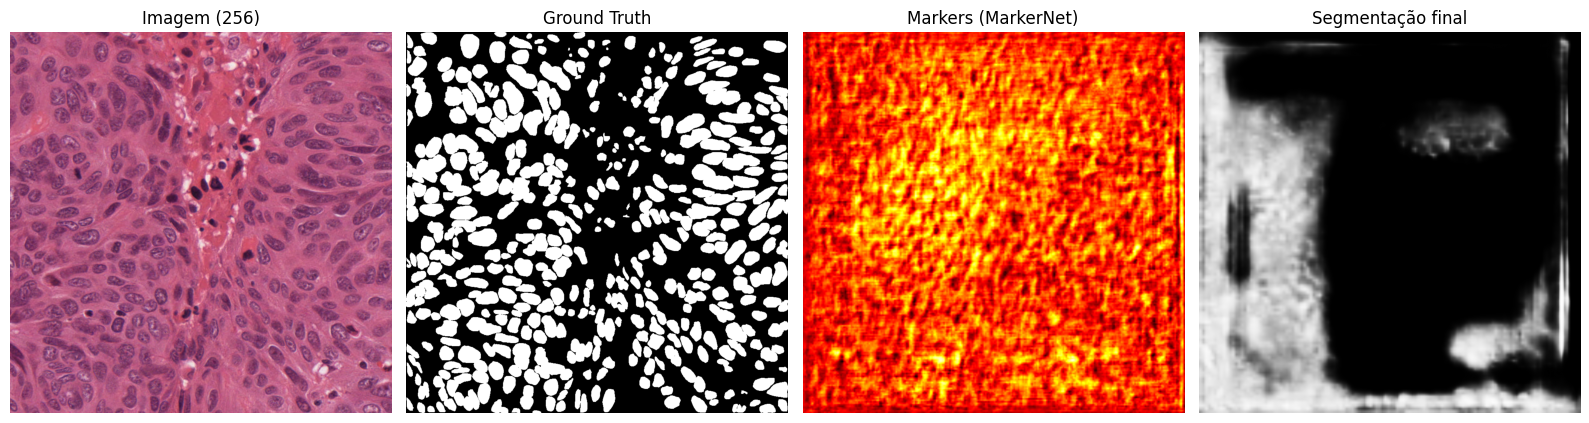

: 

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
axes[0].imshow(image_np)
axes[0].set_title("Imagem (256)")
axes[1].imshow(gt_np, cmap="gray")
axes[1].set_title("Ground Truth")
axes[2].imshow(out["markers"][0, 0].detach().cpu().numpy(), cmap="hot")
axes[2].set_title("Markers (MarkerNet)")
axes[3].imshow(out["segmentation"][0, 0].detach().cpu().numpy(), cmap="gray")
axes[3].set_title("Segmentação final")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

: 